# Two-Stage Fine-Tuning of REVE on BCI Competition IV-2a

## 1 — Load REVE from Hugging Face

In [ ]:
from huggingface_hub import login

HF_TOKEN = "TOKENEEOKOEKRE"

login(token=HF_TOKEN)
print("Login successful.")

/home/mo3ad/miniconda3/envs/gpu_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Login successful.


In [2]:
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(
    "brain-bzh/reve-base", trust_remote_code=True, torch_dtype="auto", token=HF_TOKEN
)
pos_bank = AutoModel.from_pretrained(
    "brain-bzh/reve-positions", trust_remote_code=True, torch_dtype="auto", token=HF_TOKEN
)

print(model)

Loading weights: 100%|██████████| 1/1 [00:00<00:00, 5336.26it/s]

Reve(
  (transformer): TransformerBackbone(
    (layers): ModuleList(
      (0-21): 22 x ModuleList(
        (0): Attention(
          (norm): RMSNorm()
          (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
          (to_out): Linear(in_features=512, out_features=512, bias=False)
          (attend): FlashAttention()
        )
        (1): FeedForward(
          (net): Sequential(
            (0): RMSNorm()
            (1): Linear(in_features=512, out_features=2722, bias=False)
            (2): GEGLU()
            (3): Linear(in_features=1361, out_features=512, bias=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    (0): Linear(in_features=200, out_features=512, bias=True)
  )
  (fourier4d): FourierEmb4D()
  (mlp4d): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=False)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (ln): LayerNorm((512,), eps=1e-05, elemen

### Classification head

The REVE base model outputs shape `[B, 22, 5, 512]` ? 22 channels, 5 time patches, hidden dim 512. We flatten this and project to 4 classes (left hand, right hand, feet, tongue), exactly as in the other notebooks.

In [3]:
dim = 22 * 5 * 512  # channels * time_patches * hidden_dim

model.final_layer = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.RMSNorm(dim),
    torch.nn.Dropout(0.1),
    torch.nn.Linear(dim, 4),
)

## 2 — Hyperparameters

**Stage 1 (LP)** uses a higher learning rate (1e-3) because only the freshly initialized head trains, there is no risk of corrupting pretrained weights.

**Stage 2 (LoRA)** uses a lower learning rate (1e-4) and LoRA rank 8, matching the reproduction codebase (`config_dt.yaml` uses rank 16 on attention only; we apply rank 8 across patch, mlp4d, attention, and ffn for broader but lighter adaptation, this keeps total added params small while touching every module type).

In [4]:
BATCH_SIZE = 64
SEED = 42

# Stage 1 — Linear Probing (all subjects)
LP_EPOCHS = 20
LP_LR = 1e-3

# Stage 2 — Per-subject LoRA fine-tuning
FT_EPOCHS = 15
FT_LR = 1e-4
LORA_RANK = 8
LORA_APPLY_TO = ("patch", "mlp4d", "attention", "ffn")

BCI_CHANNELS = [
    "Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2", "POz",
]

positions = pos_bank(BCI_CHANNELS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [5]:
from transformers import set_seed

set_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 3 — Load BCI Competition IV-2a

We load the full dataset from MOABB (9 subjects, 22 channels, 4 motor-imagery classes).


Each subject's data is split 70 / 15 / 15 into train / val / test, and the pooled loaders are simply the union of all subject-level train / val / test splits (so there is no data leakage between stages).

In [6]:
from functools import partial
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from scipy.signal import butter, lfilter
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype="band")

paradigm = MotorImagery(n_classes=4, resample=250, fmin=8, fmax=30)
bci_dataset = BNCI2014_001()
X, y, metadata = paradigm.get_data(dataset=bci_dataset)

b, a = butter_bandpass(8, 30, 250)
X = lfilter(b, a, X, axis=-1)

label_map = {"left_hand": 0, "right_hand": 1, "feet": 2, "tongue": 3}
y = np.array([label_map[label] for label in y])

subjects = sorted(metadata["subject"].unique())
print(f"Subjects: {subjects}  —  total trials: {len(y)}")


class BCIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {"data": self.X[idx], "labels": self.y[idx]}


def collate_fn(batch, positions):
    x = torch.stack([b["data"] for b in batch])
    y = torch.tensor([b["labels"] for b in batch])
    pos = positions.repeat(len(batch), 1, 1)
    return {"sample": x, "label": y.long(), "pos": pos}


def make_loaders(dataset, batch_size, positions):
    """70/15/15 split → train/val/test DataLoaders."""
    n = len(dataset)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    n_test = n - n_train - n_val

    gen = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val, n_test], generator=gen
    )
    cfn = partial(collate_fn, positions=positions)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=cfn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=cfn)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=cfn)
    return train_loader, val_loader, test_loader


# ---- Per-subject datasets ------------------------------------------------
subject_datasets = {}
for subj in subjects:
    mask = (metadata["subject"].values == subj)
    subject_datasets[subj] = BCIDataset(X[mask], y[mask])
    print(f"  Subject {subj}: {mask.sum()} trials")

# ---- Pooled dataset (union of all subjects) --------------------------------
full_dataset = BCIDataset(X, y)
pooled_train, pooled_val, pooled_test = make_loaders(full_dataset, BATCH_SIZE, positions)
print(f"\nPooled loaders — train: {len(pooled_train.dataset)}, val: {len(pooled_val.dataset)}, test: {len(pooled_test.dataset)}")

Choosing from all possible events


Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]  —  total trials: 5184
  Subject 1: 576 trials
  Subject 2: 576 trials
  Subject 3: 576 trials
  Subject 4: 576 trials
  Subject 5: 576 trials
  Subject 6: 576 trials
  Subject 7: 576 trials
  Subject 8: 576 trials
  Subject 9: 576 trials

Pooled loaders — train: 3628, val: 777, test: 779


## 4 — Training and evaluation helpers

Same as Fouad's Noteboook

In [7]:
from tqdm.auto import tqdm
from sklearn.metrics import (
    balanced_accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize
import copy

criterion = torch.nn.CrossEntropyLoss()


def train_one_epoch(model, optimizer, loader):
    model.train()
    pbar = tqdm(loader, desc="Training", total=len(loader))
    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    for batch_data in pbar:
        data = batch_data["sample"].to(device, non_blocking=True)
        target = batch_data["label"].to(device, non_blocking=True)
        pos = batch_data["pos"].to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast(dtype=torch.float16, device_type=device_type):
            output = model(data, pos)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})


def eval_model(model, loader):
    model.eval()
    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    all_decisions, all_targets, all_probs = [], [], []
    score, count = 0, 0

    with torch.inference_mode():
        for batch_data in loader:
            data = batch_data["sample"].to(device, non_blocking=True)
            target = batch_data["label"].to(device, non_blocking=True)
            pos = batch_data["pos"].to(device, non_blocking=True)

            with torch.amp.autocast(dtype=torch.float16, device_type=device_type):
                output = model(data, pos)

            decisions = torch.argmax(output, dim=1)
            score += (decisions == target).int().sum().item()
            count += target.shape[0]
            all_decisions.append(decisions)
            all_targets.append(target)
            all_probs.append(output)

    gt = torch.cat(all_targets).cpu().numpy()
    pr = torch.cat(all_decisions).cpu().numpy()
    pr_probs = torch.softmax(torch.cat(all_probs).float(), dim=1).cpu().numpy()

    acc = score / count
    balanced_acc = balanced_accuracy_score(gt, pr)
    kappa = cohen_kappa_score(gt, pr)
    f1 = f1_score(gt, pr, average="weighted")
    auroc = roc_auc_score(gt, pr_probs, multi_class="ovr")
    auc_pr = average_precision_score(
        label_binarize(gt, classes=[0, 1, 2, 3]), pr_probs, average="macro"
    )

    return {
        "acc": acc,
        "balanced_acc": balanced_acc,
        "cohen_kappa": kappa,
        "f1": f1,
        "auroc": auroc,
        "auc_pr": auc_pr,
    }

## 5 — Stage 1: Linear Probing on All Subjects

- The entire REVE backbone is **frozen** (`requires_grad=False`).
- Only the freshly initialized classification head (`final_layer`) is trained.
- We use **all 9 subjects pooled** so the head learns a general mapping from REVE features to motor-imagery classes.
- Early stopping via `ReduceLROnPlateau` on validation balanced accuracy; we checkpoint the best head weights.



In [8]:
# Freeze backbone, only head is trainable
for param in model.parameters():
    param.requires_grad = False
for param in model.final_layer.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Stage 1 — trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f} %)")

model.to(device)

optimizer_lp = torch.optim.AdamW(model.final_layer.parameters(), lr=LP_LR)
scheduler_lp = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lp, mode="max", factor=0.5, patience=3
)

best_val_acc = 0.0
best_head_state = None

for epoch in range(LP_EPOCHS):
    print(f"\n[LP] Epoch {epoch + 1}/{LP_EPOCHS}")
    train_one_epoch(model, optimizer_lp, pooled_train)
    metrics = eval_model(model, pooled_val)
    b_acc = metrics["balanced_acc"]
    if b_acc > best_val_acc:
        best_val_acc = b_acc
        best_head_state = copy.deepcopy(model.final_layer.state_dict())
    print(f"  val balanced_acc: {b_acc:.4f}  (best: {best_val_acc:.4f})")
    scheduler_lp.step(b_acc)

model.final_layer.load_state_dict(best_head_state)
lp_test = eval_model(model, pooled_test)
print(f"\n--- Stage 1 (LP) test results ---")
for k, v in lp_test.items():
    print(f"  {k}: {v:.4f}")

Stage 1 — trainable: 281,604 / 69,471,236 (0.41 %)



[LP] Epoch 1/20


Training: 100%|██████████| 57/57 [00:06<00:00,  8.15it/s, loss=3.0273] 


  val balanced_acc: 0.3382  (best: 0.3382)

[LP] Epoch 2/20


Training: 100%|██████████| 57/57 [00:06<00:00,  8.98it/s, loss=3.2754]


...

  val balanced_acc: 0.4543  (best: 0.4575)

[LP] Epoch 19/20


Training: 100%|██████████| 57/57 [00:06<00:00,  8.88it/s, loss=0.2776]


  val balanced_acc: 0.4429  (best: 0.4575)

[LP] Epoch 20/20


Training: 100%|██████████| 57/57 [00:06<00:00,  8.77it/s, loss=0.2426]


  val balanced_acc: 0.4294  (best: 0.4575)

--- Stage 1 (LP) test results ---
  acc: 0.4172
  balanced_acc: 0.4296
  cohen_kappa: 0.2297
  f1: 0.4080
  auroc: 0.6960
  auc_pr: 0.4549


### Save the Stage-1 checkpoint

We deep-copy the full model state after LP. Every subject in Stage 2 will start from this exact checkpoint, ensuring a fair and reproducible comparison.

In [9]:
lp_checkpoint = copy.deepcopy(model.state_dict())
print("Stage-1 checkpoint saved (in memory).")

Stage-1 checkpoint saved (in memory).


## 6 — Stage 2: Per-Subject LoRA Fine-Tuning

**For each of the 9 subjects:**

1. **Reload** the Stage-1 checkpoint so every subject starts from the same LP-trained model.
2. **Inject LoRA adapters** into the backbone using `peft`. We target `to_qkv` and `to_out` (attention projections) as well as FFN layers — the same modules the reproduction codebase targets. The rank is 8 with `lora_alpha = 2 * rank = 16` for stable scaling.
3. **Mark trainable**: only the LoRA parameters + the classification head.
4. **Fine-tune** on that subject's data alone (their own 70/15/15 split).
5. **Checkpoint** the best model per subject.
6. **Evaluate** on the subject's held-out test set.

Because each subject gets its own LoRA adapter, the model can learn subject-specific patterns without interfering with other subjects. This is the core mechanism for reducing inter-subject volatility.

In [10]:
from peft import LoraConfig, get_peft_model
import sys, types

sys.path.insert(0, "../reve-repro-main/src")


def apply_lora(base_model, rank=LORA_RANK):
    """Wrap the base REVE model with LoRA adapters and return the peft model."""
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=2 * rank,
        target_modules=["to_qkv", "to_out"],
        lora_dropout=0.05,
        bias="none",
        modules_to_save=["final_layer"],
    )
    peft_model = get_peft_model(base_model, lora_config)
    return peft_model


# Quick sanity check: count LoRA params on a throwaway copy
_tmp = copy.deepcopy(model)
_tmp = apply_lora(_tmp)
_tmp.print_trainable_parameters()
del _tmp

trainable params: 822,276 || all params: 70,293,512 || trainable%: 1.1698


### Run Stage 2 loop over all 9 subjects

In [11]:
subject_results = {}

for subj in subjects:
    print(f"\n{'='*60}")
    print(f"  Stage 2 — Subject {subj}")
    print(f"{'='*60}")

    # 1. Fresh copy from LP checkpoint
    model.load_state_dict(lp_checkpoint)

    # 2. Apply LoRA
    lora_model = apply_lora(model)
    lora_model.to(device)

    # 3. Per-subject data loaders
    subj_train, subj_val, subj_test = make_loaders(
        subject_datasets[subj], BATCH_SIZE, positions
    )
    print(f"  Trials — train: {len(subj_train.dataset)}, "
          f"val: {len(subj_val.dataset)}, test: {len(subj_test.dataset)}")

    # 4. Optimizer & scheduler
    trainable_params = [p for p in lora_model.parameters() if p.requires_grad]
    optimizer_ft = torch.optim.AdamW(trainable_params, lr=FT_LR)
    scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ft, mode="max", factor=0.5, patience=3
    )

    best_val = 0.0
    best_state = None

    for epoch in range(FT_EPOCHS):
        print(f"\n  [FT-S{subj}] Epoch {epoch + 1}/{FT_EPOCHS}")
        train_one_epoch(lora_model, optimizer_ft, subj_train)
        m = eval_model(lora_model, subj_val)
        b_acc = m["balanced_acc"]
        if b_acc > best_val:
            best_val = b_acc
            best_state = copy.deepcopy(lora_model.state_dict())
        print(f"    val balanced_acc: {b_acc:.4f}  (best: {best_val:.4f})")
        scheduler_ft.step(b_acc)

    # 5. Evaluate best model on subject's test set
    lora_model.load_state_dict(best_state)
    test_metrics = eval_model(lora_model, subj_test)
    subject_results[subj] = test_metrics

    print(f"\n  --- Subject {subj} test results ---")
    for k, v in test_metrics.items():
        print(f"    {k}: {v:.4f}")

    # 6. Unwrap LoRA so the base `model` can be re-used cleanly next iteration
    model = lora_model.merge_and_unload()

print("\nStage 2 complete for all subjects.")


  Stage 2 — Subject 1
  Trials — train: 403, val: 86, test: 87

  [FT-S1] Epoch 1/15


Training: 100%|██████████| 7/7 [00:02<00:00,  2.76it/s, loss=1.7949]


    val balanced_acc: 0.8220  (best: 0.8220)

  [FT-S1] Epoch 2/15


Training: 100%|██████████| 7/7 [00:05<00:00,  1.27it/s, loss=0.2522]


    val balanced_acc: 0.8248  (best: 0.8248)

  [FT-S1] Epoch 3/15


...

    val balanced_acc: 0.8300  (best: 0.9161)

  [FT-S9] Epoch 14/15


Training: 100%|██████████| 7/7 [00:02<00:00,  2.99it/s, loss=0.0047]


    val balanced_acc: 0.8408  (best: 0.9161)

  [FT-S9] Epoch 15/15


Training: 100%|██████████| 7/7 [00:02<00:00,  2.97it/s, loss=0.0329]


    val balanced_acc: 0.8408  (best: 0.9161)

  --- Subject 9 test results ---
    acc: 0.8621
    balanced_acc: 0.8636
    cohen_kappa: 0.8150
    f1: 0.8628
    auroc: 0.9606
    auc_pr: 0.9129

Stage 2 complete for all subjects.


## 7 — Results: Per-Subject Metrics & Volatility Analysis



In [12]:
import pandas as pd

rows = []
for subj in subjects:
    row = {"subject": subj}
    row.update(subject_results[subj])
    rows.append(row)

df = pd.DataFrame(rows).set_index("subject")

metric_cols = ["acc", "balanced_acc", "cohen_kappa", "f1", "auroc", "auc_pr"]
mean_row = df[metric_cols].mean()
std_row = df[metric_cols].std()

summary = pd.DataFrame([mean_row, std_row], index=["mean", "std"])
df_display = pd.concat([df[metric_cols], summary])

print("=" * 70)
print("  Two-Stage Fine-Tuning — Per-Subject Results")
print("=" * 70)
print(df_display.round(4).to_string())
print()
print(f"Mean balanced accuracy: {mean_row['balanced_acc']:.4f} +/- {std_row['balanced_acc']:.4f}")
print(f"Mean Cohen's kappa:     {mean_row['cohen_kappa']:.4f} +/- {std_row['cohen_kappa']:.4f}")

  Two-Stage Fine-Tuning — Per-Subject Results
         acc  balanced_acc  cohen_kappa      f1   auroc  auc_pr
1     0.8621        0.8646       0.8146  0.8639  0.9535  0.8862
2     0.6897        0.6867       0.5853  0.6956  0.8864  0.8020
3     0.7816        0.7821       0.7062  0.7815  0.9367  0.8559
4     0.8391        0.8419       0.7850  0.8408  0.9482  0.8952
5     0.7471        0.7319       0.6531  0.7461  0.9356  0.8761
6     0.7816        0.7920       0.7082  0.7805  0.9131  0.8261
7     0.8046        0.8045       0.7366  0.8077  0.9258  0.8372
8     0.7816        0.7912       0.7072  0.7800  0.9291  0.8637
9     0.8621        0.8636       0.8150  0.8628  0.9606  0.9129
mean  0.7944        0.7954       0.7235  0.7954  0.9321  0.8617
std   0.0559        0.0589       0.0754  0.0553  0.0225  0.0354

Mean balanced accuracy: 0.7954 +/- 0.0589
Mean Cohen's kappa:     0.7235 +/- 0.0754


### Visualisation: per-subject balanced accuracy

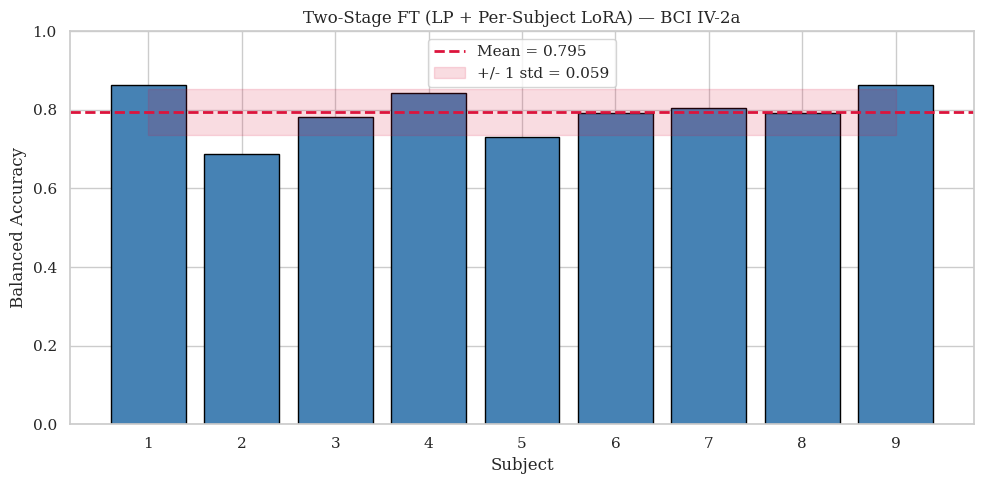

In [13]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 5))
    subj_labels = [str(s) for s in subjects]
    bal_accs = [subject_results[s]["balanced_acc"] for s in subjects]
    bars = ax.bar(subj_labels, bal_accs, color="steelblue", edgecolor="black")
    ax.axhline(mean_row["balanced_acc"], color="crimson", linestyle="--", linewidth=2,
               label=f"Mean = {mean_row['balanced_acc']:.3f}")
    ax.fill_between(
        range(len(subjects)),
        mean_row["balanced_acc"] - std_row["balanced_acc"],
        mean_row["balanced_acc"] + std_row["balanced_acc"],
        alpha=0.15, color="crimson", label=f"+/- 1 std = {std_row['balanced_acc']:.3f}",
    )
    ax.set_xlabel("Subject")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title("Two-Stage FT (LP + Per-Subject LoRA) — BCI IV-2a")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed — skipping plot.")